<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/ML_Project_Week10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Title
#**Potato Leaf Disease Detection using Image Classification**

#**Project Description**

This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.


#**Objectives**

● Understand image classification using deep learning

● Perform data preprocessing and augmentation

● Train and evaluate a CNN-based model


#**Dataset details**
Classes:

○ Early Blight

○ Late Blight

○ Healthy

● Data Type: Image dataset (high-resolution leaf images)

#1. Data Understanding

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


In [ ]:
import os
print(os.listdir(path))

['PlantVillage', 'PotatoPlants']


In [ ]:
print(os.listdir(os.path.join(path,"PlantVillage")))

['PlantVillage']


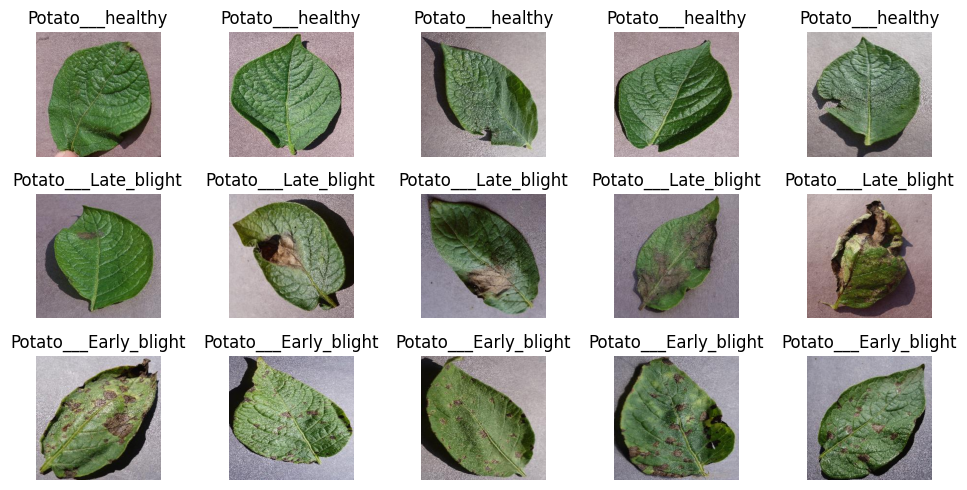

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
dataset_path = os.path.join(path,"PlantVillage","PlantVillage")

i = 1
plt.figure(figsize=(10,5))

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path,class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)[:5]
        for img_name in images:
            img_path = os.path.join(class_path,img_name)

            if os.path.isfile(img_path):
                img = Image.open(img_path)
                plt.subplot(3,5,i)
                plt.imshow(img)
                plt.title(class_name)
                plt.axis('off')
                i += 1

plt.tight_layout()
plt.show()

#2. Data Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
img_height = 224
img_width = 224
batch_size = 32

In [ ]:
for class_name in os.listdir(path):
  class_path=os.path.join(path,class_name)

  if os.path.isdir(class_path):
    count=len(os.listdir(class_path))
    print(count,class_name)

1 PlantVillage
3 PotatoPlants


In [ ]:
data_generator = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

#3. Model Building



In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
n_classes = 3

cnn_model = models.Sequential([

    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])

#4. Model Training

In [ ]:
import os

dataset_path = os.path.join(path,"PlantVillage","PlantVillage")
print(os.listdir(dataset_path))

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


In [ ]:
import pandas as pd

data = []

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path,label)

    if os.path.isdir(class_path):

        for img in os.listdir(class_path):
            img_path = os.path.join(class_path,img)

            if os.path.isfile(img_path):
                data.append([img_path,label])

df = pd.DataFrame(data, columns=["image_path","label"])
df.head()

,image_path,label
0,/kaggle/input/potato-plant-diseases-data/Plant...,Potato___healthy
1,/kaggle/input/potato-plant-diseases-data/Plant...,Potato___healthy
2,/kaggle/input/potato-plant-diseases-data/Plant...,Potato___healthy
3,/kaggle/input/potato-plant-diseases-data/Plant...,Potato___healthy
4,/kaggle/input/potato-plant-diseases-data/Plant...,Potato___healthy


In [ ]:
train_size = int(0.7*len(df))
val_size = int(0.15*len(df))
test_size = int(0.15*len (df))
print(f"train_size: {train_size} -----val_size:{val_size}-----test_size:{test_size}")

train_data = df.iloc[:train_size]
#df.iloc[:,52500]
val_data = df.iloc[train_size:train_size + val_size]
#df.iloc[52500:52500+11250]
test_data = df.iloc[train_size + val_size:]
#df.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size: 1506 -----val_size:322-----test_size:322
Training set size: 1506
Validation set size: 322
Test set size: 324


In [ ]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)


val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    stratify=temp_data["label"],
    random_state=42
)

In [ ]:
print(train_data['label'].value_counts())
print(val_data['label'].value_counts())
print(test_data['label'].value_counts())

label
Potato___Early_blight    700
Potato___Late_blight     700
Potato___healthy         106
Name: count, dtype: int64
label
Potato___Late_blight     150
Potato___Early_blight    150
Potato___healthy          23
Name: count, dtype: int64
label
Potato___Early_blight    150
Potato___Late_blight     150
Potato___healthy          23
Name: count, dtype: int64


In [ ]:
train_generator = data_generator.flow_from_dataframe(
    dataframe=train_data,
    x_col="image_path",
    y_col="label",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 1506 validated image filenames belonging to 3 classes.


In [ ]:
validation_generator = data_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col="image_path",
    y_col="label",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 323 validated image filenames belonging to 3 classes.


In [ ]:
test_generator = data_generator.flow_from_dataframe(
    dataframe=test_data,
    x_col="image_path",
    y_col="label",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 323 validated image filenames belonging to 3 classes.


In [ ]:
print("Train:", train_generator.class_indices)
print("Validation:", validation_generator.class_indices)
print("Test:", test_generator.class_indices)

Train: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}
Validation: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}
Test: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in validation_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(validation_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 48)
Train Label Shape: (32, 3)

Validation Shape: (32, 224, 224, 3) (Batches = 11)
Validation Label Shape: (32, 3)

Test Shape: (32, 224, 224, 3) (Batches = 11)
Test Label Shape: (32, 3)



In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
cnn_model.compile(loss=categorical_crossentropy,
                  optimizer=Adam(),
                  metrics=['accuracy'])

In [ ]:
Cnn=cnn_model.fit(train_generator,
                  epochs=30,validation_data=validation_generator,
                  verbose=1)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.4914 - loss: 0.9157 - val_accuracy: 0.4768 - val_loss: 0.8895
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.5969 - loss: 0.8206 - val_accuracy: 0.7028 - val_loss: 0.7179
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.7158 - loss: 0.6759 - val_accuracy: 0.8050 - val_loss: 0.5954
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.7616 - loss: 0.5865 - val_accuracy: 0.8359 - val_loss: 0.5107
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.8327 - loss: 0.4516 - val_accuracy: 0.8824 - val_loss: 0.3476
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.8552 - loss: 0.3855 - val_accuracy: 0.8669 - val_loss: 0.3592
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.8586 - loss: 0.3841 - val_accuracy: 0.8359 - val_loss: 0.4293
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.8254 - loss: 0.4516 - val_accuracy: 0.8978 - v

#5. Model Evaluation


In [ ]:
#accuracy
test_loss, test_accuracy = cnn_model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9752 - loss: 0.0741
Test Accuracy: 0.9752321839332581


In [ ]:
#predictions
import numpy as np
pred = cnn_model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step


In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[146   4   0]
 [  3 147   0]
 [  0   1  22]]


In [ ]:
#classification  report
from sklearn.metrics import classification_report
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.99      0.99       150
 Potato___Late_blight       0.98      0.99      0.98       150
     Potato___healthy       1.00      0.96      0.98        23

             accuracy                           0.98       323
            macro avg       0.99      0.98      0.98       323
         weighted avg       0.98      0.98      0.98       323

